# Step 1: Install and Import Required Libraries

This section installs necessary NLP and visualization libraries.
We use:
- spaCy (for NLP and NER)
- nltk (tokenization support)
- pandas (data handling)
- matplotlib & seaborn (visualization)
- wordcloud (theme visualization)

In [1]:
# Install required packages
!pip install -q spacy nltk seaborn wordcloud

# Download spaCy English model
!python -m spacy download en_core_web_sm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import nltk
from wordcloud import WordCloud
from collections import Counter
import re

# Load NLP model
nlp = spacy.load("en_core_web_sm")

# Improve plot aesthetics
sns.set(style="whitegrid", context="talk")
plt.rcParams['figure.figsize'] = (10,6)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 80.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


# Step 2: Mount Google Drive and Load Dataset

This loads 'premises.csv' from:
'/content/drive/MyDrive/premises.csv'

Basic error handling ensures:
- File exists
- Required column 'premise' exists

In [2]:
from google.colab import drive
import os

drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/premises.csv'

if not os.path.exists(file_path):
    raise FileNotFoundError(f"File not found at {file_path}")

# Read the CSV assuming no header, and then assign the column name
df = pd.read_csv(file_path, header=None)

required_column = "premise"
df.columns = [required_column] # Assign the column name after loading

# The column existence check is now redundant since we just assigned it, but can be kept for other scenarios.
# if required_column not in df.columns:
#     raise ValueError(f"Column '{required_column}' not found in dataset. Available columns: {df.columns}")

df = df.dropna(subset=[required_column])
df.reset_index(drop=True, inplace=True)

print(f"Dataset loaded successfully with {len(df)} premises.")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully with 100 premises.


,premise
0,"In a quest for justice, a passionate and ideal..."
1,"In 1960s rural southern town, a determined you..."
2,"In 18th century Native American tribe, a young..."
3,"In 1970s Detroit, a disillusioned African Amer..."
4,"A young, idealistic African American prosecuto..."


# Step 3: Gender Pronoun Frequency Analysis

We analyze pronoun distribution:
- Masculine: he, him, his
- Feminine: she, her, hers
- Neutral: they, them, their

This identifies narrative gender representation bias.

/tmp/ipython-input-186/3048621325.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pronoun_data, x="Category", y="Frequency", palette="deep")


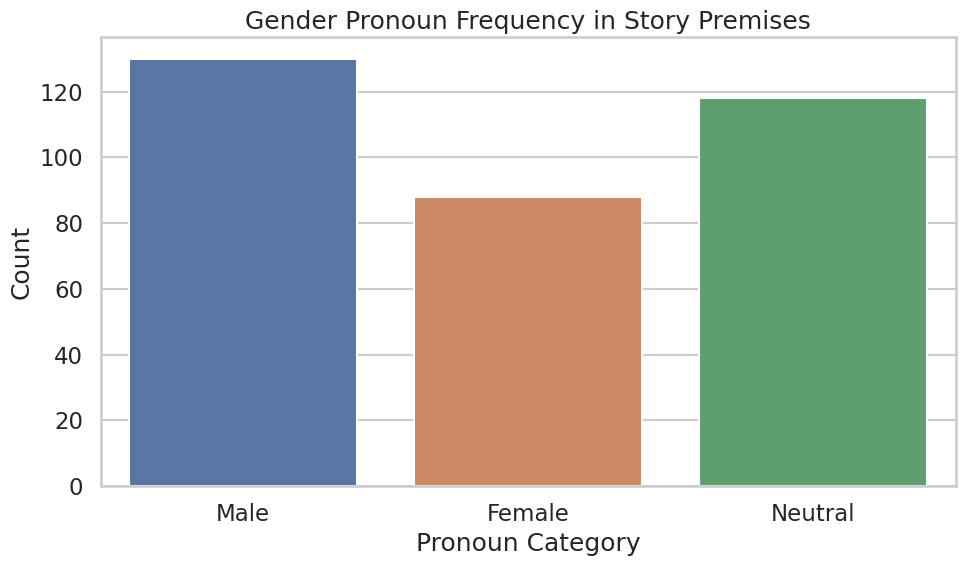

In [3]:
male_pronouns = ["he", "him", "his"]
female_pronouns = ["she", "her", "hers"]
neutral_pronouns = ["they", "them", "their"]

male_count = 0
female_count = 0
neutral_count = 0

for text in df["premise"]:
    tokens = re.findall(r'\b\w+\b', text.lower())
    male_count += sum(token in male_pronouns for token in tokens)
    female_count += sum(token in female_pronouns for token in tokens)
    neutral_count += sum(token in neutral_pronouns for token in tokens)

pronoun_data = pd.DataFrame({
    "Category": ["Male", "Female", "Neutral"],
    "Frequency": [male_count, female_count, neutral_count]
})

# Plot
plt.figure()
sns.barplot(data=pronoun_data, x="Category", y="Frequency", palette="deep")
plt.title("Gender Pronoun Frequency in Story Premises")
plt.ylabel("Count")
plt.xlabel("Pronoun Category")
plt.tight_layout()
plt.show()

# Step 4: Adjective Extraction Associated with Gendered Subjects

We extract adjectives appearing in sentences mentioning:
- Male pronouns
- Female pronouns

This helps identify stereotypical character traits.

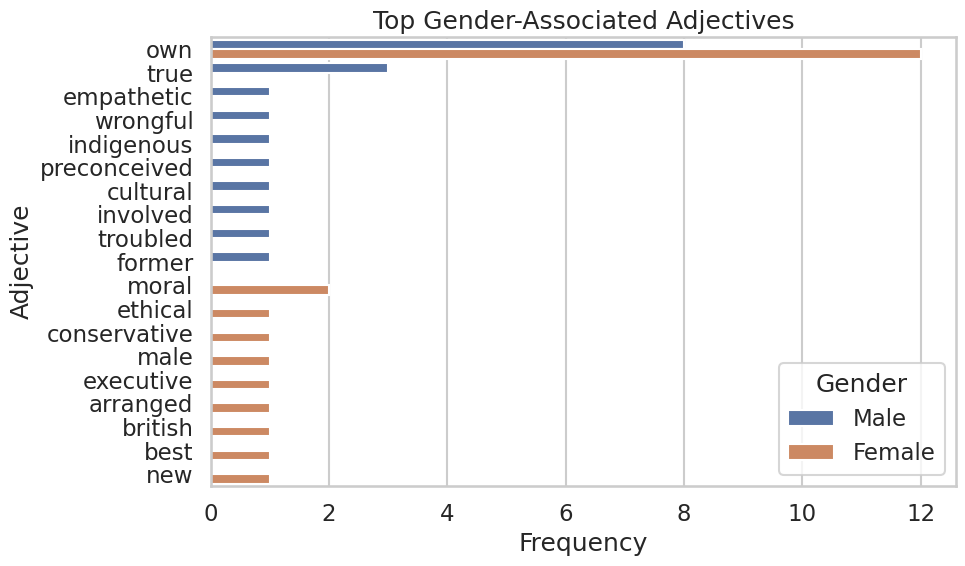

In [4]:
male_adjectives = []
female_adjectives = []

for text in df["premise"]:
    doc = nlp(text)
    for token in doc:
        if token.text.lower() in male_pronouns:
            for child in token.head.children:
                if child.pos_ == "ADJ":
                    male_adjectives.append(child.text.lower())
        if token.text.lower() in female_pronouns:
            for child in token.head.children:
                if child.pos_ == "ADJ":
                    female_adjectives.append(child.text.lower())

male_adj_counts = Counter(male_adjectives).most_common(10)
female_adj_counts = Counter(female_adjectives).most_common(10)

adj_df = pd.DataFrame({
    "Adjective": [x[0] for x in male_adj_counts + female_adj_counts],
    "Frequency": [x[1] for x in male_adj_counts + female_adj_counts],
    "Gender": ["Male"]*len(male_adj_counts) + ["Female"]*len(female_adj_counts)
})

plt.figure()
sns.barplot(data=adj_df, y="Adjective", x="Frequency", hue="Gender")
plt.title("Top Gender-Associated Adjectives")
plt.xlabel("Frequency")
plt.ylabel("Adjective")
plt.tight_layout()
plt.show()

# Step 5: Named Entity Recognition (Cultural & Geographic References)

We extract:
- GPE (countries, cities)
- NORP (nationalities, religious groups)

This reveals cultural representation diversity.

/tmp/ipython-input-186/682695035.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=entity_df, y="Entity", x="Frequency", palette="viridis")


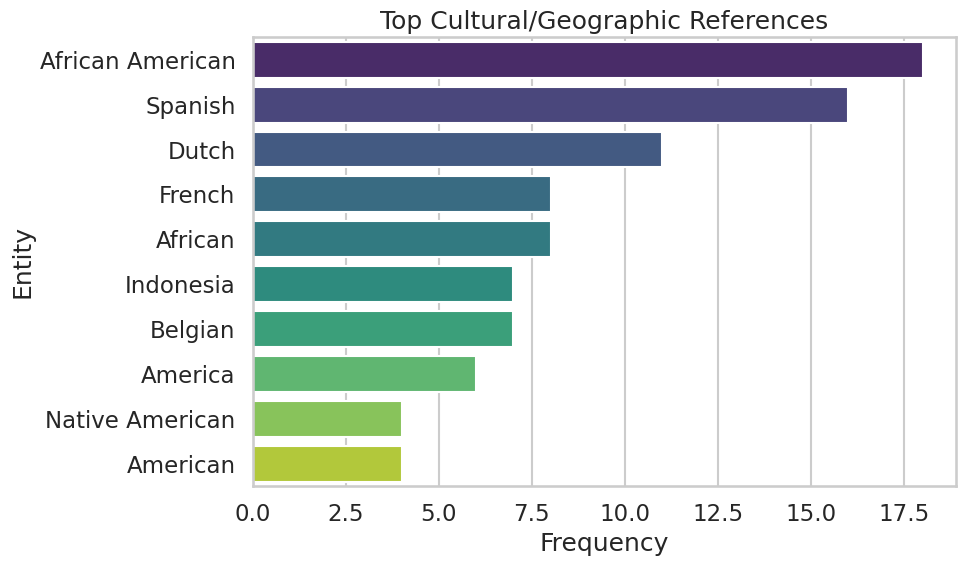

In [5]:
entities = []

for text in df["premise"]:
    doc = nlp(text)
    for ent in doc.ents:
        if ent.label_ in ["GPE", "NORP"]:
            entities.append(ent.text)

entity_counts = Counter(entities).most_common(10)

entity_df = pd.DataFrame(entity_counts, columns=["Entity", "Frequency"])

plt.figure()
sns.barplot(data=entity_df, y="Entity", x="Frequency", palette="viridis")
plt.title("Top Cultural/Geographic References")
plt.xlabel("Frequency")
plt.ylabel("Entity")
plt.tight_layout()
plt.show()

# Step 6: Extract Most Common Thematic Keywords

We remove stopwords and extract frequent nouns as themes.

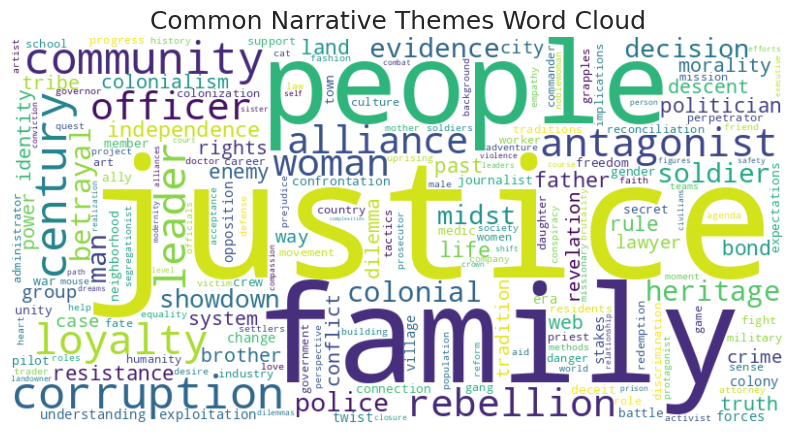

In [6]:
from spacy.lang.en.stop_words import STOP_WORDS

theme_words = []

for text in df["premise"]:
    doc = nlp(text)
    for token in doc:
        if token.pos_ == "NOUN" and token.text.lower() not in STOP_WORDS:
            theme_words.append(token.text.lower())

theme_counts = Counter(theme_words)

# Word Cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(theme_counts)

plt.figure()
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Common Narrative Themes Word Cloud")
plt.show()

# Step 7: Automated Statistical Summary

This generates a concise textual overview for inclusion in an academic report.

In [7]:
total_pronouns = male_count + female_count + neutral_count

male_pct = (male_count/total_pronouns)*100 if total_pronouns else 0
female_pct = (female_count/total_pronouns)*100 if total_pronouns else 0
neutral_pct = (neutral_count/total_pronouns)*100 if total_pronouns else 0

print("\n===== BIAS DETECTION SUMMARY =====\n")

print(f"Total Premises Analyzed: {len(df)}")
print("\nGender Pronoun Distribution:")
print(f"Male: {male_count} ({male_pct:.2f}%)")
print(f"Female: {female_count} ({female_pct:.2f}%)")
print(f"Neutral: {neutral_count} ({neutral_pct:.2f}%)")

print("\nTop Cultural References:")
for ent, freq in entity_counts:
    print(f"- {ent}: {freq}")

print("\nTop Narrative Themes:")
for theme, freq in theme_counts.most_common(10):
    print(f"- {theme}: {freq}")

print("\nInterpretation Guidance:")
print("• A high male-to-female pronoun ratio may indicate gender imbalance.")
print("• Repeated adjectives tied to one gender suggest stereotyping.")
print("• Limited geographic diversity indicates cultural centralization.")
print("• Dominant recurring themes may reveal narrative pattern bias.")


===== BIAS DETECTION SUMMARY =====

Total Premises Analyzed: 100

Gender Pronoun Distribution:
Male: 130 (38.69%)
Female: 88 (26.19%)
Neutral: 118 (35.12%)

Top Cultural References:
- African American: 18
- Spanish: 16
- Dutch: 11
- French: 8
- African: 8
- Indonesia: 7
- Belgian: 7
- America: 6
- Native American: 4
- American: 4

Top Narrative Themes:
- justice: 37
- family: 24
- people: 20
- corruption: 18
- century: 17
- community: 17
- leader: 15
- loyalty: 15
- antagonist: 14
- woman: 13

Interpretation Guidance:
• A high male-to-female pronoun ratio may indicate gender imbalance.
• Repeated adjectives tied to one gender suggest stereotyping.
• Limited geographic diversity indicates cultural centralization.
• Dominant recurring themes may reveal narrative pattern bias.
